In [1]:
# General imports
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
from copy import deepcopy
import jax

# Euclid software
# JAX approach to Background and Perturbations
from cloelite.cosmology.jax_cosmology import JAXBackground
from cloelite.cosmology.jax_cosmology import JAXLinearPerturbations
from cloelite.cosmology.jax_cosmology import JAXNonLinearPerturbations

# CAMB approach to Background and Perturbations
from cloelite.cosmology.camb_cosmology import CAMBBackground
from cloelite.cosmology.camb_cosmology import CAMBLinearPerturbations
from cloelite.cosmology.camb_cosmology import CAMBNonLinearPerturbations

from cloelite.observables.two_point import AngularTwoPoint
from cloelite.observables import photo
import euclidlib as el

# Plot style
import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=1)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=20)

In [2]:
# Read the dndz
z_pos, dndz_pos = el.photo.redshift_distributions('../data/nz.pos.fits')
z_she, dndz_she = el.photo.redshift_distributions('../data/nz.wl.fits')

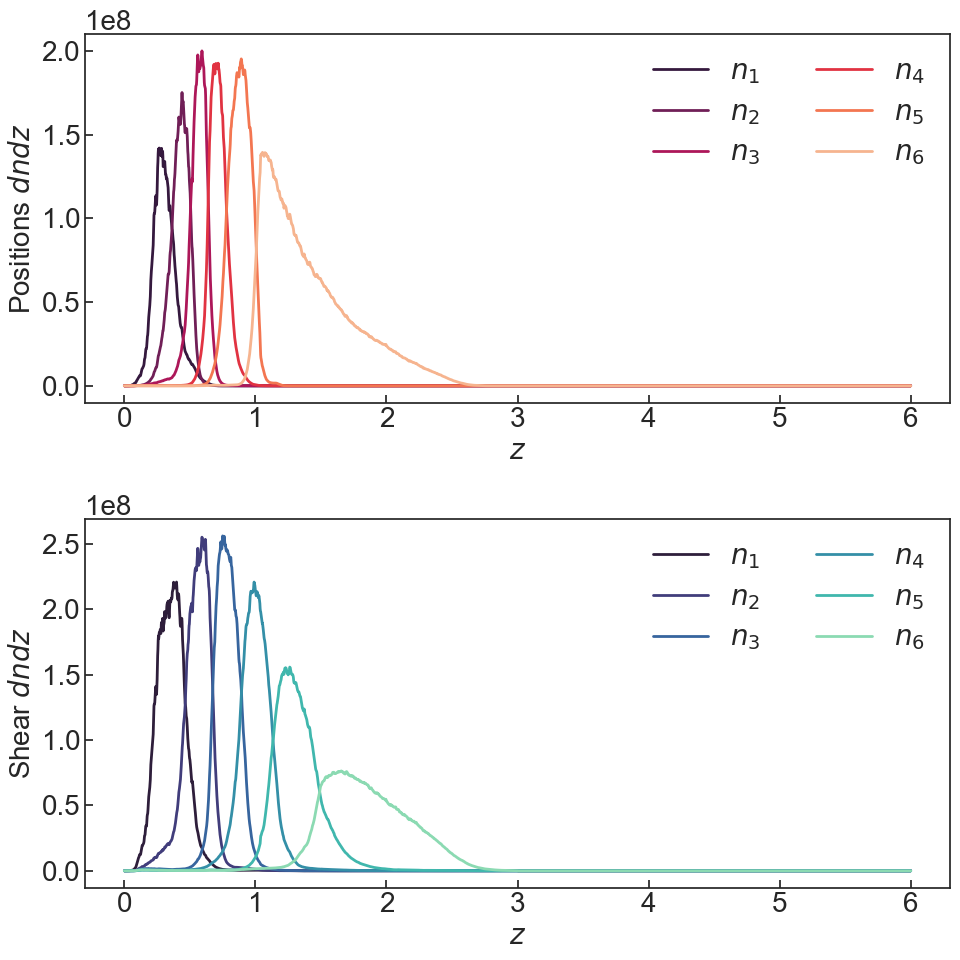

In [3]:
# Plot the dndz
i = 0
j = 0
fig, axs = plt.subplots(2, 1, figsize=(10,10))
for ax in axs.flatten():
    ax.tick_params(axis='both',which='both',direction='in')
for key in dndz_pos.keys():
    axs[0].plot(z_pos, dndz_pos[key], label = '$n_{{{}}}$'.format(i+1), linewidth=2, color=sns.color_palette("rocket", len(dndz_pos.keys()))[i])
    i=i+1
for key in dndz_she.keys():
    axs[1].plot(z_she, dndz_she[key], label = '$n_{{{}}}$'.format(j+1), linewidth=2, color=sns.color_palette("mako", len(dndz_pos.keys()))[j])
    j=j+1
axs[0].set_xlabel(r'$z$')
axs[0].set_ylabel(r'Positions $dndz$ ')
axs[0].legend(frameon=False, ncol=2)
axs[1].set_xlabel(r'$z$')
axs[1].set_ylabel(r'Shear $dndz$ ')
axs[1].legend(frameon=False, ncol=2);
plt.tight_layout()

In [4]:
# Normalise dndz
dndz_pos_norm = deepcopy(dndz_pos)
for key in dndz_pos.keys():
    dndz_pos_norm[key] = dndz_pos[key] / integrate.trapezoid(
                        dndz_pos[key], z_pos)

dndz_she_norm = deepcopy(dndz_she)
for key in dndz_she.keys():
    dndz_she_norm[key] = dndz_she[key] / integrate.trapezoid(
                        dndz_she[key], z_she)

# Let's sample internally the n(z) we want and we return an array (move to euclidlib even NT complains)
my_dndz_pos = np.vstack(list(dndz_pos_norm.values()))
myz = np.linspace(1e-3, 3., 256)
my_dndz_pos_norm = np.zeros([6, 256])
for i in range(6):
    my_dndz_pos_norm[i,:] = np.interp(myz, z_pos, my_dndz_pos[i,:])

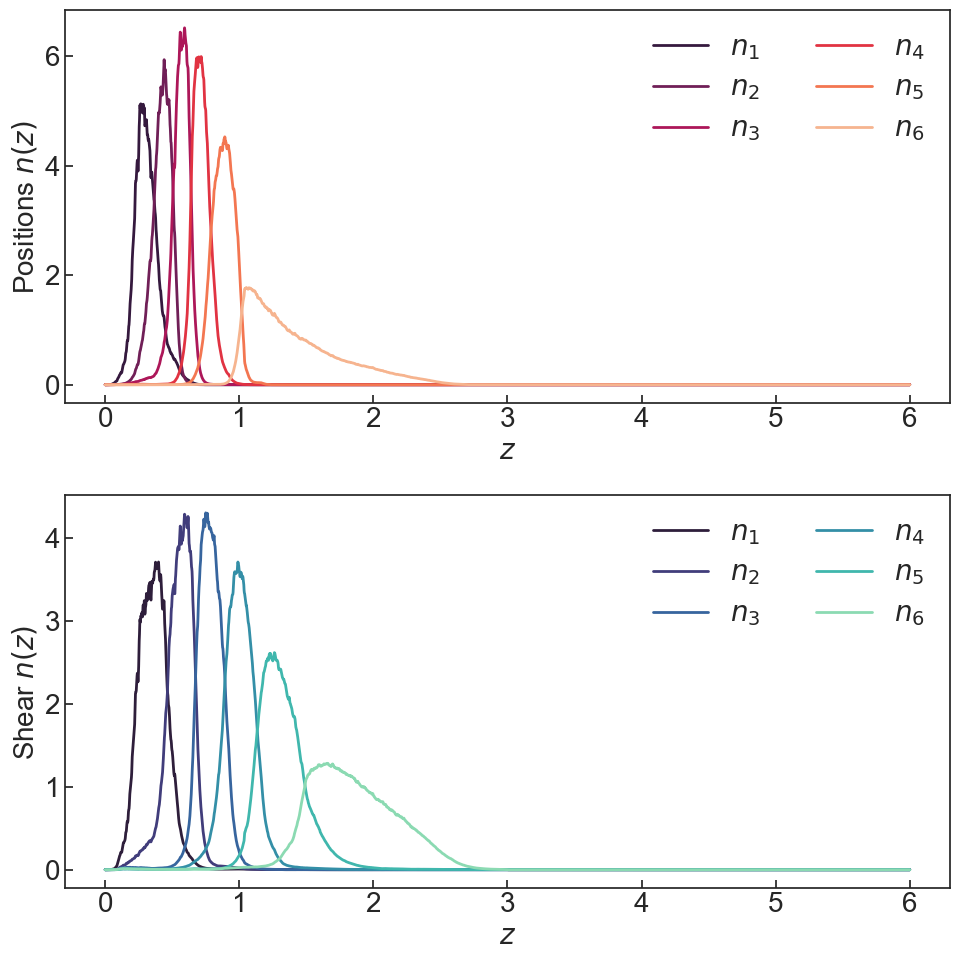

In [5]:
# Plot the dndz
i = 0
j = 0
fig, axs = plt.subplots(2, 1, figsize=(10,10))
for ax in axs.flatten():
    ax.tick_params(axis='both',which='both',direction='in')
for key in dndz_pos.keys():
    axs[0].plot(z_pos, dndz_pos_norm[key], label = '$n_{{{}}}$'.format(i+1), linewidth=2, color=sns.color_palette("rocket", len(dndz_pos.keys()))[i])
    i=i+1
for key in dndz_she.keys():
    axs[1].plot(z_she, dndz_she_norm[key], label = '$n_{{{}}}$'.format(j+1), linewidth=2, color=sns.color_palette("mako", len(dndz_pos.keys()))[j])
    j=j+1
axs[0].set_xlabel(r'$z$')
axs[0].set_ylabel(r'Positions $n(z)$ ')
axs[0].legend(frameon=False, ncol=2)
axs[1].set_xlabel(r'$z$')
axs[1].set_ylabel(r'Shear $n(z)$ ')
axs[1].legend(frameon=False, ncol=2);
plt.tight_layout()

In [6]:
# Initialize Background cosmology
# Cosmology parameters
H0 =  67.7
h = H0/100.
sigma8 = 0.8277
Omm = 0.3097
Omc = 0.26067408193677466
Omb = 0.04902591806322532
w = -1
wa = 0

#background = JAXBackground(H0=H0,Omc=Omc,Omb=Omb, w=w, wa=wa, sigma8=sigma8, Omk = 0.0, ns = 0.96, gamma_MG = 0.545)
background_jax = JAXBackground(67.74, 0.0486, 0.2589, 0.0, 0.8159, 2e-9, 0.9667, -1.0, 0.0, 0.55)
background_camb = CAMBBackground(H0=H0,Omc=Omc,Omb=Omb, w=w, wa=wa, sigma8=sigma8, Omk = 0.0, ns = 0.96, As = 2e-9, gamma_MG = 0.545)

In [7]:
# Initialize Linear and NonLinearPerturbations

redshifts=myz

linear_pert = JAXLinearPerturbations(background_jax) #CAMBLinearPerturbations(background_camb, redshifts=myz)#JAXLinearPerturbations(background_jax)
nonlinear_pert = JAXNonLinearPerturbations(linear_pert)

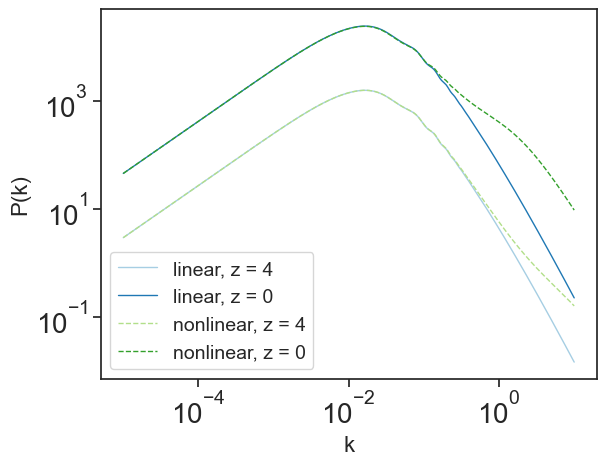

In [8]:
ks = np.logspace(-5,1,300)

plt.loglog(ks, linear_pert.linear_matter_power_spectrum(ks,4), label = 'linear, z = 4')
plt.loglog(ks, linear_pert.linear_matter_power_spectrum(ks,0), label = 'linear, z = 0')

plt.loglog(ks, nonlinear_pert.nonlinear_matter_power_spectrum(ks,4), '--', label = 'nonlinear, z = 4')
plt.loglog(ks, nonlinear_pert.nonlinear_matter_power_spectrum(ks,0), '--', label = 'nonlinear, z = 0')

plt.ylabel('P(k)', fontsize=16);
plt.xlabel('k', fontsize=16);
plt.legend(fontsize = 14, loc=3);

In [9]:
# We define the tracers, for the moment only galaxy clustering (position)

tracer_she = photo.ShearTracer(nonlinear_pert,
                            dndz=my_dndz_pos_norm,
                            z = z_she,
                            intrinsic_aligment_model='zNLA',
                            nuisance_params={'param1': 1.0})

tracer_pos = photo.PositionsTracer(nonlinear_pert,
                            dndz=my_dndz_pos_norm,
                            z = myz,
                            magnification_bias_model = 'linear',
                            galaxy_bias_model= 'linear',
                            nuisance_params={'param1': 1.0})

print('The shape of the window kernel for galaxy positions is: {}'.format(tracer_pos.get_window_positions(myz).shape))

The shape of the window kernel for galaxy positions is: (6, 256)


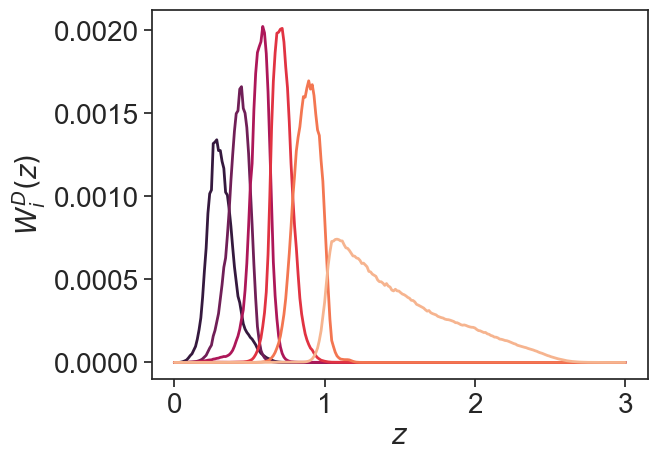

In [10]:
# Note the D for positions (euclidlib internal map pointer :) )
for i in dndz_pos.keys():
    plt.plot(myz, tracer_pos.get_window_positions(myz)[i-1], linewidth=2, color=sns.color_palette("rocket", len(dndz_pos.keys()))[i-1])
plt.xlabel(r'$z$')
plt.ylabel(r'$W^D_i(z)$');

In [11]:
# Let's define the angular power spectra (C_ells)
twopt = AngularTwoPoint(tracer_pos, tracer_pos)
# We need to pass the ell range
cl = twopt.get_Cl()

In [12]:
# Time of computation for cl
%timeit twopt.get_Cl()

699 ms ± 21.2 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


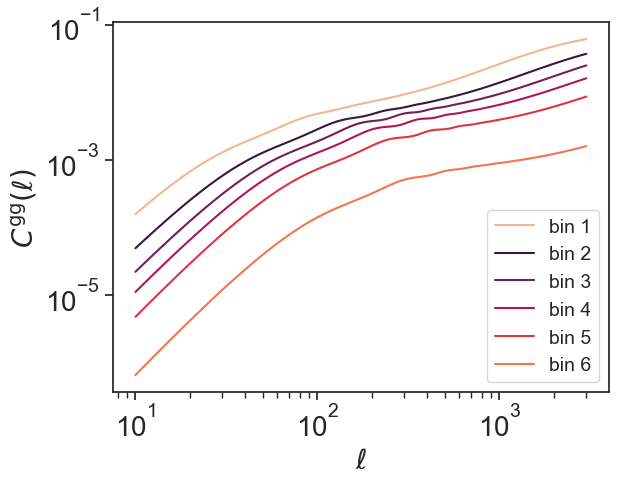

In [13]:
ell_range = np.logspace(1., np.log10(3000), 100)

for i in range(len(dndz_pos.keys())):
    plt.loglog(ell_range, (2*ell_range+1)*ell_range*cl[:,i,i], color=sns.color_palette("rocket", len(dndz_pos.keys()))[i-1], linewidth=1.5, label = 'bin {}'.format(i+1))
plt.xlabel(r'$\ell$')
plt.ylabel(r'$C^{\rm gg}(\ell)$');
plt.legend(fontsize=14);
